# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

In [1]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from visualize_utils import (
    compute_prediction_metrics,
    compute_seed_paired_drop,
    exact_prediction_for_checkpoint,
    find_selected_checkpoint,
    float_token_pattern,
    plot_mean_ci_curve,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
    warn_incomplete_seed_sets,
)

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

NETWORK = "mimic4models/keras_models/lstm.py"
EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXPECTED_EPOCHS = 100

from visualize_utils import (
    load_prediction_csv as _load_prediction_frame,
    paired_patient_bootstrap as _paired_patient_bootstrap,
)

EXP2A_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP2A_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP2A_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP2A_OUTPUT_DIR = EXP2A_RESULTS_DIR / "plots"
EXP2A_HORIZONS = [12, 24, 48, 96, 168]
EXP2A_TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]

# Keep exploratory cells permissive by default; final reported analyses should require complete seed sets.
EXP2A_ONLY_COMPLETE_RUNS = False

EXP2A_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def load_prediction_frame(path):
    return _load_prediction_frame(path)


def paired_patient_bootstrap(reference_df, comparison_df, metric, n_boot=2000, random_state=12345):
    result = _paired_patient_bootstrap(reference_df, comparison_df, metric, n_boot=n_boot, random_state=random_state)
    return {
        "reference_1h": result["left_metric"],
        "comparison": result["right_metric"],
        "difference": result["difference"],
        "ci_low": result["ci_low"],
        "ci_high": result["ci_high"],
        "n_patients": result["n_patients"],
        "n_stays": result["n_stays"],
        "n_boot_valid": result["n_boot_valid"],
    }


# Experiment 2A - Does frequency matter more for short horizons?

## Experiment question and expected evidence

Question: At a fixed prediction time of 24h after ICU admission, is the cost of coarser measurement frequency larger for short prediction horizons than for long prediction horizons?

Quantity: Performance-vs-resolution plots show AUPRC/AUROC by temporal resolution, with one curve per prediction horizon. Degradation plots compute Delta(h, r, s) = M(h, 1h, s) - M(h, r, s) within each seed, then summarize the paired drops across seeds with 95% Student-t CIs.

Evidence we are looking for: H2 is supported by larger positive degradation at short horizons, especially 12h, with smaller degradation at longer horizons. The longer horizons may form a plateau; perfect monotonic decline from 12h to 168h is not required.

Caveat: Raw AUPRC should not be compared directly across horizons because outcome prevalence differs by horizon. Delta relative to 1h and AUROC degradation are safer for cross-horizon sensitivity comparisons.

In [2]:
def parse_exp2a_run(path):
    m = re.search(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9]+(?:\.[0-9]+)?)(?=\.|$)"
        r".*\.seed(?P<seed>\d+)(?:\.|$)",
        path.name,
    )
    if m is None:
        return None
    return {"horizon": int(m.group("horizon")), "timestep": float(m.group("timestep")), "seed": int(m.group("seed"))}


exp2a_val_rows = []
for horizon in EXP2A_HORIZONS:
    log_dir = EXP2A_RESULTS_DIR / "{}h".format(horizon) / "keras_logs"
    if not log_dir.exists():
        print("Missing log directory:", log_dir)
        continue
    for log_path in sorted(log_dir.glob("*.csv")):
        run = parse_exp2a_run(log_path)
        if run is None:
            print("Skipping unrecognized filename:", log_path.name)
            continue
        if run["horizon"] != horizon or run["timestep"] not in EXP2A_TIMESTEPS or run["seed"] not in EXPECTED_MODEL_SEEDS:
            continue
        best = read_validation_log(log_path, only_complete=EXP2A_ONLY_COMPLETE_RUNS)
        if best is None:
            print("Skipping empty/incomplete run:", log_path.name)
            continue
        checkpoint = find_selected_checkpoint(log_path, best["best_csv_epoch"])
        exp2a_val_rows.append({
            **run,
            **best,
            "log_path": str(log_path),
            "checkpoint": None if checkpoint is None else str(checkpoint),
        })

exp2a_val_runs = pd.DataFrame(exp2a_val_rows).sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A validation-selected checkpoints", exp2a_val_runs, max_rows=300)
warn_incomplete_seed_sets(exp2a_val_runs, ["horizon", "timestep"])


Experiment 2A validation-selected checkpoints


,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,seed,selected_validation_epoch,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,93,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,0,93,1.0,0.469834,0.730083,0.730083,0.469834,0.730083
1,44,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,1,44,1.0,0.476230,0.731720,0.731720,0.476230,0.731720
2,91,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,2,91,1.0,0.471504,0.736019,0.736019,0.471504,0.736019
3,92,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,3,92,1.0,0.471724,0.732311,0.732311,0.471724,0.732311
4,86,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,4,86,1.0,0.479264,0.734050,0.734050,0.479264,0.734050
5,63,0.471126,63,/heinz-georgenas/users/mingzhul/Simultaneous-E...,64,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,0,63,2.0,0.471126,0.727930,0.727930,0.471126,0.727930
6,37,0.469171,37,/heinz-georgenas/users/mingzhul/Simultaneous-E...,38,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,1,37,2.0,0.469171,0.727814,0.727814,0.469171,0.727814
7,64,0.470541,64,/heinz-georgenas/users/mingzhul/Simultaneous-E...,65,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,2,64,2.0,0.470541,0.729149,0.729149,0.470541,0.729149
8,73,0.471056,73,/heinz-georgenas/users/mingzhul/Simultaneous-E...,74,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,3,73,2.0,0.471056,0.730254,0.730254,0.471056,0.730254
9,70,0.472521,70,/heinz-georgenas/users/mingzhul/Simultaneous-E...,71,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,4,70,2.0,0.472521,0.730681,0.730681,0.472521,0.730681


PARTIAL SEED SET (168, 1.0): observed=[0, 1, 2, 3] missing=[4] extra=[]


## Validation performance vs temporal resolution

Question: Within each prediction horizon, how does validation performance change as temporal resolution becomes coarser?

Quantity: X-axis is temporal resolution; y-axis is validation AUPRC or AUROC at the validation-AUPRC-selected epoch; curves are prediction horizons; error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: Similar fine-resolution performance with degradation at coarse resolutions suggests frequency sensitivity.

Caveat: Do not interpret raw AUPRC levels across horizons as directly comparable baselines because prevalence differs across horizons.


Experiment 2A validation AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004850,0.478561,0.468861,12,0.473711,5,0.003906,0.001747,1.0
1,0.001498,0.472381,0.469385,12,0.470883,5,0.001206,0.000539,2.0
2,0.001566,0.446294,0.443162,12,0.444728,5,0.001261,0.000564,4.0
3,0.003737,0.424239,0.416765,12,0.420502,5,0.003010,0.001346,8.0
4,0.003262,0.419302,0.412777,12,0.416039,5,0.002628,0.001175,12.0
5,0.001571,0.353816,0.350673,12,0.352244,5,0.001266,0.000566,24.0
6,0.005057,0.604218,0.594105,24,0.599161,5,0.004073,0.001821,1.0
7,0.003026,0.598713,0.592662,24,0.595687,5,0.002437,0.001090,2.0
8,0.003451,0.584589,0.577687,24,0.581138,5,0.002779,0.001243,4.0
9,0.001764,0.580559,0.577031,24,0.578795,5,0.001421,0.000635,8.0



Experiment 2A validation AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.002825,0.735662,0.730012,12,0.732837,5,0.002275,0.001017,1.0
1,0.001623,0.730789,0.727542,12,0.729166,5,0.001307,0.000585,2.0
2,0.002777,0.716739,0.711185,12,0.713962,5,0.002237,0.001000,4.0
3,0.001660,0.689128,0.685808,12,0.687468,5,0.001337,0.000598,8.0
4,0.002733,0.675831,0.670366,12,0.673099,5,0.002201,0.000984,12.0
5,0.002373,0.627947,0.623200,12,0.625574,5,0.001911,0.000855,24.0
6,0.002661,0.699597,0.694275,24,0.696936,5,0.002143,0.000958,1.0
7,0.002497,0.699236,0.694242,24,0.696739,5,0.002011,0.000899,2.0
8,0.001840,0.690314,0.686635,24,0.688475,5,0.001482,0.000663,4.0
9,0.001653,0.682442,0.679136,24,0.680789,5,0.001331,0.000595,8.0


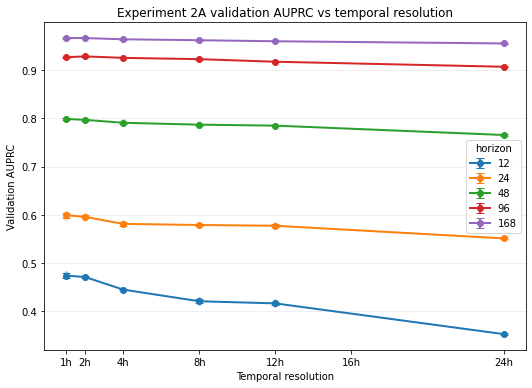

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auprc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


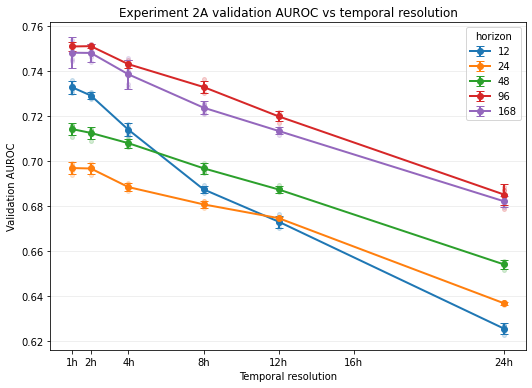

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auroc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [3]:
exp2a_val_auprc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auprc")
exp2a_val_auroc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auroc")
show_table("Experiment 2A validation AUPRC summary", exp2a_val_auprc_summary, max_rows=200)
show_table("Experiment 2A validation AUROC summary", exp2a_val_auroc_summary, max_rows=200)

plot_mean_ci_curve(
    exp2a_val_auprc_summary, "timestep", "Validation AUPRC",
    "Experiment 2A validation AUPRC vs temporal resolution",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auprc_vs_resolution_ci95.png",
    EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
    xlabel="Temporal resolution", raw_df=exp2a_val_runs, raw_metric="val_auprc",
)
plot_mean_ci_curve(
    exp2a_val_auroc_summary, "timestep", "Validation AUROC",
    "Experiment 2A validation AUROC vs temporal resolution",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auroc_vs_resolution_ci95.png",
    EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
    xlabel="Temporal resolution", raw_df=exp2a_val_runs, raw_metric="val_auroc",
)

## Validation degradation relative to 1h

Question: Is the validation-performance cost of coarsening larger for near-term prediction?

Quantity: Delta(h, r, s) = M(h, 1h, s) - M(h, r, s), computed within seed before summarizing. X-axis is prediction horizon; one curve is shown for each temporal resolution; error bars are 95% Student-t CIs across paired seed-level drops.

Evidence we are looking for: Larger positive Delta at the 12h horizon than at longer horizons supports H2.

Caveat: Delta does not need to decrease perfectly monotonically across horizons. For AUPRC, compare degradation rather than raw cross-horizon levels.


Experiment 2A validation AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004742,0.007570,-0.001913,12,0.002828,5,0.003819,0.001708,2.0
1,0.004110,0.033093,0.024874,12,0.028983,5,0.003310,0.001480,4.0
2,0.006761,0.059970,0.046448,12,0.053209,5,0.005445,0.002435,8.0
3,0.002864,0.060536,0.054808,12,0.057672,5,0.002307,0.001032,12.0
4,0.004962,0.126429,0.116505,12,0.121467,5,0.003997,0.001787,24.0
5,0.002214,0.005689,0.001260,24,0.003474,5,0.001783,0.000798,2.0
6,0.005515,0.023538,0.012508,24,0.018023,5,0.004442,0.001986,4.0
7,0.004621,0.024987,0.015745,24,0.020366,5,0.003722,0.001664,8.0
8,0.007940,0.029858,0.013979,24,0.021918,5,0.006395,0.002860,12.0
9,0.005806,0.053965,0.042353,24,0.048159,5,0.004676,0.002091,24.0



Experiment 2A validation AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.002427,0.006098,0.001244,12,0.003671,5,0.001955,0.000874,2.0
1,0.004647,0.023522,0.014228,12,0.018875,5,0.003742,0.001674,4.0
2,0.001726,0.047095,0.043643,12,0.045369,5,0.001390,0.000622,8.0
3,0.003099,0.062837,0.056639,12,0.059738,5,0.002496,0.001116,12.0
4,0.004771,0.112034,0.102492,12,0.107263,5,0.003843,0.001718,24.0
5,0.003731,0.003929,-0.003534,24,0.000198,5,0.003005,0.001344,2.0
6,0.001714,0.010176,0.006748,24,0.008462,5,0.001381,0.000617,4.0
7,0.002903,0.019050,0.013244,24,0.016147,5,0.002338,0.001046,8.0
8,0.002861,0.025131,0.019409,24,0.022270,5,0.002304,0.001030,12.0
9,0.002820,0.062921,0.057282,24,0.060102,5,0.002271,0.001016,24.0


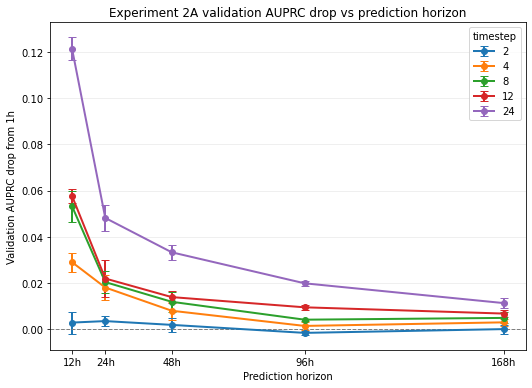

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auprc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


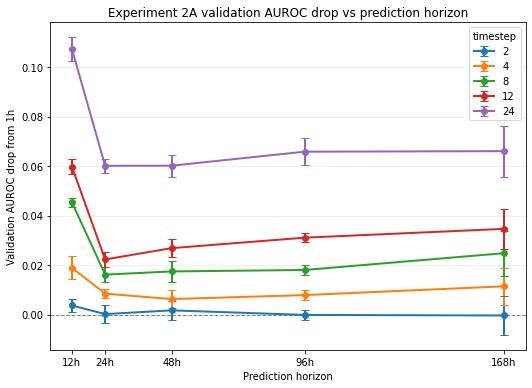

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auroc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [4]:
exp2a_val_auprc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auprc", drop_col="drop")
exp2a_val_auroc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auroc", drop_col="drop")
exp2a_val_auprc_drops = exp2a_val_auprc_drops[exp2a_val_auprc_drops["timestep"] != 1.0].copy()
exp2a_val_auroc_drops = exp2a_val_auroc_drops[exp2a_val_auroc_drops["timestep"] != 1.0].copy()
exp2a_val_auprc_drop_summary = summarize_with_t_ci(exp2a_val_auprc_drops, ["horizon", "timestep"], "drop")
exp2a_val_auroc_drop_summary = summarize_with_t_ci(exp2a_val_auroc_drops, ["horizon", "timestep"], "drop")
show_table("Experiment 2A validation AUPRC drop from 1h", exp2a_val_auprc_drop_summary, max_rows=200)
show_table("Experiment 2A validation AUROC drop from 1h", exp2a_val_auroc_drop_summary, max_rows=200)

plot_mean_ci_curve(
    exp2a_val_auprc_drop_summary, "horizon", "Validation AUPRC drop from 1h",
    "Experiment 2A validation AUPRC drop vs prediction horizon",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auprc_drop_vs_horizon_ci95.png",
    EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
    xlabel="Prediction horizon", zero_line=True,
)
plot_mean_ci_curve(
    exp2a_val_auroc_drop_summary, "horizon", "Validation AUROC drop from 1h",
    "Experiment 2A validation AUROC drop vs prediction horizon",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auroc_drop_vs_horizon_ci95.png",
    EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
    xlabel="Prediction horizon", zero_line=True,
)

## Test performance vs temporal resolution

Question: Do the validation-selected checkpoints show the same frequency-sensitivity pattern on the held-out test set?

Quantity: Test AUPRC/AUROC are computed only from prediction files linked exactly to the validation-selected checkpoint filename. Error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: The same threshold-like or short-horizon-sensitive degradation pattern on test data strengthens the validation finding.

Caveat: Test data are not used for model selection. Missing exact prediction files are reported rather than replaced by loose `(horizon, timestep, seed)` or mtime-based matches.


Experiment 2A exact validation-selected test predictions


,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,prediction_path,seed,selected_validation_epoch,test_auprc,test_auroc,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,93,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,93,0.491179,0.746718,1.0,0.469834,0.730083,0.730083,0.469834,0.730083
1,44,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,44,0.490433,0.741809,1.0,0.476230,0.731720,0.731720,0.476230,0.731720
2,63,0.471126,63,/heinz-georgenas/users/mingzhul/Simultaneous-E...,64,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,63,0.484856,0.739190,2.0,0.471126,0.727930,0.727930,0.471126,0.727930
3,37,0.469171,37,/heinz-georgenas/users/mingzhul/Simultaneous-E...,38,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,37,0.480740,0.740271,2.0,0.469171,0.727814,0.727814,0.469171,0.727814
4,64,0.470541,64,/heinz-georgenas/users/mingzhul/Simultaneous-E...,65,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,64,0.484753,0.740403,2.0,0.470541,0.729149,0.729149,0.470541,0.729149
5,73,0.471056,73,/heinz-georgenas/users/mingzhul/Simultaneous-E...,74,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,73,0.479901,0.738241,2.0,0.471056,0.730254,0.730254,0.471056,0.730254
6,99,0.445222,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,99,0.463364,0.733742,4.0,0.445222,0.714791,0.714791,0.445222,0.714791
7,80,0.446050,80,/heinz-georgenas/users/mingzhul/Simultaneous-E...,81,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,80,0.465747,0.735433,4.0,0.446050,0.714950,0.714950,0.446050,0.714950
8,92,0.443186,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,92,0.471104,0.735723,4.0,0.443186,0.711262,0.711262,0.443186,0.711262
9,66,0.443601,66,/heinz-georgenas/users/mingzhul/Simultaneous-E...,67,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,66,0.466318,0.731448,4.0,0.443601,0.712094,0.712094,0.443601,0.712094


,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,reason,seed,selected_validation_epoch,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,91,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,91,1.0,0.471504,0.736019,0.736019,0.471504,0.736019
1,92,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,92,1.0,0.471724,0.732311,0.732311,0.471724,0.732311
2,86,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,86,1.0,0.479264,0.734050,0.734050,0.479264,0.734050
3,70,0.472521,70,/heinz-georgenas/users/mingzhul/Simultaneous-E...,71,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,70,2.0,0.472521,0.730681,0.730681,0.472521,0.730681
4,82,0.598876,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,83,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,82,1.0,0.598876,0.695536,0.695536,0.598876,0.695536
5,87,0.597837,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,87,1.0,0.597837,0.698371,0.698371,0.597837,0.698371
6,81,0.593212,81,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,81,1.0,0.593212,0.693935,0.693935,0.593212,0.693935
7,95,0.592266,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,95,2.0,0.592266,0.696849,0.696849,0.592266,0.696849
8,84,0.796358,84,/heinz-georgenas/users/mingzhul/Simultaneous-E...,85,True,48,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,84,1.0,0.796358,0.710600,0.710600,0.796358,0.710600
9,92,0.800524,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,48,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,92,1.0,0.800524,0.715425,0.715425,0.800524,0.715425



Experiment 2A missing exact test predictions
PARTIAL SEED SET (12, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (12, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (24, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (24, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (48, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (48, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (96, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (96, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (168, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (168, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]

Experiment 2A test AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004735,0.495541,0.486071,12,0.490806,2,0.000527,0.000373,1.0
1,0.004156,0.486719,0.478406,12,0.482563,4,0.002612,0.001306,2.0
2,0.003701,0.470781,0.463378,12,0.467079,5,0.002981,0.001333,4.0
3,0.005576,0.417952,0.406800,12,0.412376,5,0.004491,0.002008,8.0
4,0.002329,0.418581,0.413923,12,0.416252,5,0.001875,0.000839,12.0
5,0.004451,0.343028,0.334126,12,0.338577,5,0.003585,0.001603,24.0
6,0.056866,0.666874,0.553142,24,0.610008,2,0.006329,0.004475,1.0
7,0.007333,0.607727,0.593062,24,0.600395,4,0.004608,0.002304,2.0
8,0.003723,0.602237,0.594792,24,0.598515,5,0.002998,0.001341,4.0
9,0.002902,0.581486,0.575683,24,0.578585,5,0.002337,0.001045,8.0



Experiment 2A test AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.031184,0.775448,0.713080,12,0.744264,2,0.003471,0.002454,1.0
1,0.001614,0.741141,0.737912,12,0.739526,4,0.001014,0.000507,2.0
2,0.002112,0.736210,0.731985,12,0.734098,5,0.001701,0.000761,4.0
3,0.003506,0.697109,0.690096,12,0.693602,5,0.002824,0.001263,8.0
4,0.002875,0.690560,0.684809,12,0.687685,5,0.002316,0.001036,12.0
5,0.004207,0.628873,0.620460,12,0.624666,5,0.003388,0.001515,24.0
6,0.032489,0.735067,0.670089,24,0.702578,2,0.003616,0.002557,1.0
7,0.003750,0.699194,0.691693,24,0.695444,4,0.002357,0.001178,2.0
8,0.002396,0.696502,0.691710,24,0.694106,5,0.001930,0.000863,4.0
9,0.001659,0.676680,0.673362,24,0.675021,5,0.001336,0.000598,8.0


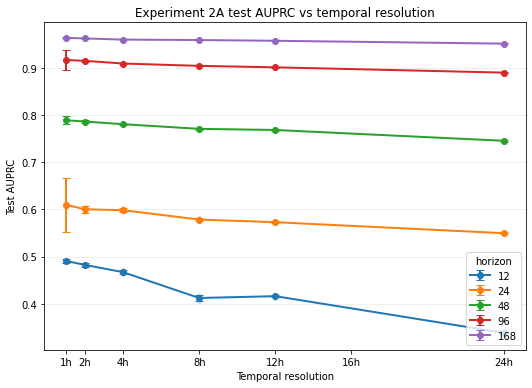

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auprc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


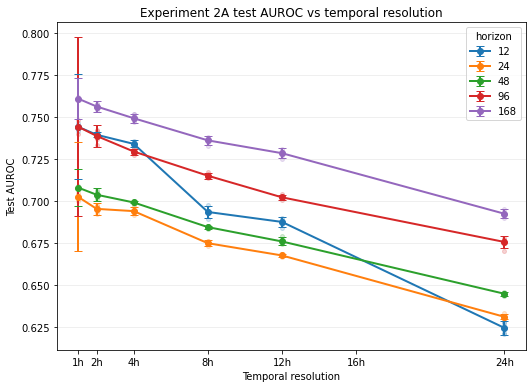

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auroc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [5]:
exp2a_test_rows = []
exp2a_missing_predictions = []

for _, row in exp2a_val_runs.iterrows():
    if not row.get("checkpoint"):
        exp2a_missing_predictions.append({**row.to_dict(), "reason": "missing selected checkpoint"})
        continue
    checkpoint = Path(row["checkpoint"])
    prediction_path = exact_prediction_for_checkpoint(EXP2A_RESULTS_DIR, "{}".format(int(row["horizon"])), checkpoint)
    if prediction_path is None:
        exp2a_missing_predictions.append({**row.to_dict(), "reason": "missing exact prediction for selected checkpoint"})
        continue
    metrics = compute_prediction_metrics(prediction_path)
    exp2a_test_rows.append({**row.to_dict(), **metrics, "prediction_path": str(prediction_path)})

exp2a_test_runs = pd.DataFrame(exp2a_test_rows)
if len(exp2a_test_runs):
    exp2a_test_runs = exp2a_test_runs.sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
exp2a_missing_predictions = pd.DataFrame(exp2a_missing_predictions)

show_table("Experiment 2A exact validation-selected test predictions", exp2a_test_runs, max_rows=300)
show_table("Experiment 2A missing exact test predictions", exp2a_missing_predictions, max_rows=300)
warn_incomplete_seed_sets(exp2a_test_runs, ["horizon", "timestep"])

if len(exp2a_test_runs):
    exp2a_test_auprc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auprc")
    exp2a_test_auroc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auroc")
    show_table("Experiment 2A test AUPRC summary", exp2a_test_auprc_summary, max_rows=200)
    show_table("Experiment 2A test AUROC summary", exp2a_test_auroc_summary, max_rows=200)
    plot_mean_ci_curve(
        exp2a_test_auprc_summary, "timestep", "Test AUPRC",
        "Experiment 2A test AUPRC vs temporal resolution",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auprc_vs_resolution_ci95.png",
        EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
        xlabel="Temporal resolution", raw_df=exp2a_test_runs, raw_metric="test_auprc",
    )
    plot_mean_ci_curve(
        exp2a_test_auroc_summary, "timestep", "Test AUROC",
        "Experiment 2A test AUROC vs temporal resolution",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auroc_vs_resolution_ci95.png",
        EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
        xlabel="Temporal resolution", raw_df=exp2a_test_runs, raw_metric="test_auroc",
    )
else:
    print("No exact validation-selected Experiment 2A test predictions available.")

## Test degradation relative to 1h

Question: On the held-out test set, is the performance cost of coarsening larger for near-term prediction?

Quantity: Test Delta(h, r, s) is computed within each seed from exact validation-selected predictions, then summarized across seeds with 95% Student-t CIs.

Evidence we are looking for: Larger positive Delta at short horizons, especially 12h, supports H2.

Caveat: The model-seed CI describes variability across trained models. It is not the same uncertainty estimate as the paired patient bootstrap below.


Experiment 2A test AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.021416,0.029423,-0.013408,12,0.008008,2,0.002384,0.001685,2.0
1,0.019878,0.046128,0.006373,12,0.026251,2,0.002212,0.001564,4.0
2,0.041018,0.118441,0.036404,12,0.077423,2,0.004565,0.003228,8.0
3,0.006967,0.080869,0.066935,12,0.073902,2,0.000775,0.000548,12.0
4,0.025714,0.176399,0.124971,12,0.150685,2,0.002862,0.002024,24.0
5,0.049744,0.055477,-0.044012,24,0.005732,2,0.005537,0.003915,2.0
6,0.092435,0.102204,-0.082665,24,0.009770,2,0.010288,0.007275,4.0
7,0.034230,0.066046,-0.002414,24,0.031816,2,0.003810,0.002694,8.0
8,0.059354,0.096001,-0.022707,24,0.036647,2,0.006606,0.004671,12.0
9,0.066363,0.127742,-0.004985,24,0.061379,2,0.007386,0.005223,24.0



Experiment 2A test AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.038050,0.042584,-0.033517,12,0.004533,2,0.004235,0.002995,2.0
1,0.041928,0.051605,-0.032251,12,0.009677,2,0.004667,0.003300,4.0
2,0.037164,0.088073,0.013746,12,0.050910,2,0.004136,0.002925,8.0
3,0.015923,0.072473,0.040627,12,0.056550,2,0.001772,0.001253,12.0
4,0.045415,0.162714,0.071884,12,0.117299,2,0.005055,0.003574,24.0
5,0.034643,0.039829,-0.029458,24,0.005185,2,0.003856,0.002727,2.0
6,0.063246,0.071361,-0.055131,24,0.008115,2,0.007039,0.004978,4.0
7,0.019507,0.046696,0.007682,24,0.027189,2,0.002171,0.001535,8.0
8,0.038092,0.072241,-0.003943,24,0.034149,2,0.004240,0.002998,12.0
9,0.029538,0.101768,0.042693,24,0.072231,2,0.003288,0.002325,24.0


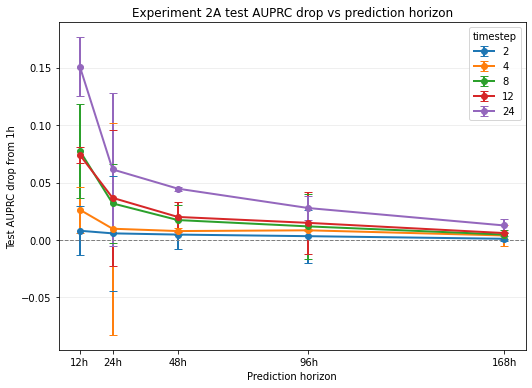

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auprc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


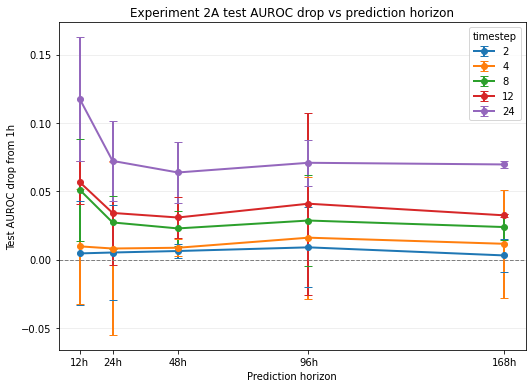

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auroc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [6]:
if len(exp2a_test_runs):
    exp2a_test_auprc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auprc", drop_col="drop")
    exp2a_test_auroc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auroc", drop_col="drop")
    exp2a_test_auprc_drops = exp2a_test_auprc_drops[exp2a_test_auprc_drops["timestep"] != 1.0].copy()
    exp2a_test_auroc_drops = exp2a_test_auroc_drops[exp2a_test_auroc_drops["timestep"] != 1.0].copy()
    exp2a_test_auprc_drop_summary = summarize_with_t_ci(exp2a_test_auprc_drops, ["horizon", "timestep"], "drop")
    exp2a_test_auroc_drop_summary = summarize_with_t_ci(exp2a_test_auroc_drops, ["horizon", "timestep"], "drop")
    show_table("Experiment 2A test AUPRC drop from 1h", exp2a_test_auprc_drop_summary, max_rows=200)
    show_table("Experiment 2A test AUROC drop from 1h", exp2a_test_auroc_drop_summary, max_rows=200)
    plot_mean_ci_curve(
        exp2a_test_auprc_drop_summary, "horizon", "Test AUPRC drop from 1h",
        "Experiment 2A test AUPRC drop vs prediction horizon",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auprc_drop_vs_horizon_ci95.png",
        EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
        xlabel="Prediction horizon", zero_line=True,
    )
    plot_mean_ci_curve(
        exp2a_test_auroc_drop_summary, "horizon", "Test AUROC drop from 1h",
        "Experiment 2A test AUROC drop vs prediction horizon",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auroc_drop_vs_horizon_ci95.png",
        EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
        xlabel="Prediction horizon", zero_line=True,
    )
else:
    print("No Experiment 2A exact test predictions available for degradation plots.")

## Paired patient bootstrap analysis

Question: Are the observed test-set differences between 1h and coarser resolutions stable to resampling the patient population?

Quantity: For AUROC, AUPRC, and Brier, predictions are paired on the same stays/patients and bootstrapped by patient. Positive differences mean the 1h/reference condition is better; for Brier this uses the reversed sign because lower Brier is better.

Evidence we are looking for: Positive paired differences whose 95% patient-bootstrap CI excludes zero indicate stable test-set degradation for that horizon/resolution/seed.

Caveat: This is a patient-population uncertainty estimate, not a model-seed CI and not a replacement for the descriptive across-seed plots above.

In [ ]:
EXP2A_BOOT_METRICS = ["auroc", "auprc", "brier"]
EXP2A_N_BOOT = int(os.environ.get("EXP2A_N_BOOT", "2000"))
EXP2A_BOOTSTRAP_SEED = 12345
exp2a_prediction_frames = {}

if len(exp2a_test_runs):
    for _, row in exp2a_test_runs.iterrows():
        exp2a_prediction_frames[(row["horizon"], row["timestep"], row["seed"])] = load_prediction_frame(row["prediction_path"])

exp2a_bootstrap_rows = []
for horizon in EXP2A_HORIZONS:
    for seed in sorted(EXPECTED_MODEL_SEEDS):
        reference_key = (horizon, 1.0, seed)
        if reference_key not in exp2a_prediction_frames:
            continue
        reference_df = exp2a_prediction_frames[reference_key]
        for timestep in [x for x in EXP2A_TIMESTEPS if x != 1]:
            comparison_key = (horizon, float(timestep), seed)
            if comparison_key not in exp2a_prediction_frames:
                continue
            comparison_df = exp2a_prediction_frames[comparison_key]
            for metric in EXP2A_BOOT_METRICS:
                result = paired_patient_bootstrap(
                    reference_df,
                    comparison_df,
                    metric=metric,
                    n_boot=EXP2A_N_BOOT,
                    random_state=EXP2A_BOOTSTRAP_SEED + horizon * 100 + timestep * 10 + seed,
                )
                exp2a_bootstrap_rows.append({
                    "horizon": horizon,
                    "timestep": timestep,
                    "seed": seed,
                    "metric": metric,
                    **result,
                })

exp2a_bootstrap = pd.DataFrame(exp2a_bootstrap_rows)
if len(exp2a_bootstrap):
    exp2a_bootstrap = exp2a_bootstrap.sort_values(["metric", "horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A seed-level paired patient-bootstrap 95% CI", exp2a_bootstrap, max_rows=300)